# Global Markets â†’ India First Hour Correlation Study

**Objective:** Use previous day's global market data to predict India's first 30 and 60 minute movement.

**Data Sources:**
- Global markets (S&P 500, NASDAQ, Nikkei, Hang Seng, DAX, FTSE, etc.): `yfinance` â€” free, no auth needed
- India (NIFTY 50) minute data: Zerodha Kite Connect API

**Logic:**
- India opens at 9:15 AM IST; US closes at ~1:30 AM IST; Japan closes at 12:00 PM IST (prev calendar day)
- For each India trading day T, the relevant global data = most recent trading day before T for each market
- Discard India days where no valid global data exists within 5 calendar days
- Discard global data days where India was closed the following trading day

In [2]:
# Cell 1 â€” Install dependencies (run once)
# !pip install kiteconnect yfinance pandas_market_calendars scipy scikit-learn seaborn statsmodels pytz

In [3]:
# Cell 2 â€” Imports
import os
import json
import time
import pickle
import warnings
from datetime import datetime, timedelta, date

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import pandas_market_calendars as mcal
from kiteconnect import KiteConnect

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

print('All imports successful')

All imports successful


In [7]:
# Cell 3 â€” Configuration (edit these)

# â”€â”€ Zerodha Kite credentials â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
API_KEY    = 'vobx4ih6afnkqiaq'     # from https://developers.kite.trade
API_SECRET = 'iocykqi71ncaguw3ba8zgpiiiuialez4'  # from your app dashboard

# â”€â”€ Date range â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
END_DATE   = date.today()
START_DATE = END_DATE - timedelta(days=3 * 365 + 5)  # ~3 years + buffer

# â”€â”€ India instrument â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# NIFTY 50 Index token on NSE. To verify, run the lookup cell below.
NIFTY_TOKEN  = 256265
NIFTY_SYMBOL = 'NSE:NIFTY 50'

# â”€â”€ Global indices (Yahoo Finance tickers) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
GLOBAL_INDICES = {
    'SP500'    : '^GSPC',      # S&P 500              â€” USA
    'NASDAQ'   : '^IXIC',      # NASDAQ Composite     â€” USA Tech
    'DOW'      : '^DJI',       # Dow Jones            â€” USA
    'NIKKEI'   : '^N225',      # Nikkei 225           â€” Japan
    'HANGSENG' : '^HSI',       # Hang Seng            â€” Hong Kong
    'SHANGHAI' : '000001.SS',  # Shanghai Composite   â€” China
    'KOSPI'    : '^KS11',      # KOSPI                â€” South Korea
    'FTSE'     : '^FTSE',      # FTSE 100             â€” UK
    'DAX'      : '^GDAXI',     # DAX                  â€” Germany
    'CAC'      : '^FCHI',      # CAC 40               â€” France
    'ASX200'   : '^AXJO',      # ASX 200              â€” Australia
    'SGX_NIFTY': 'NKD=F',      # Nikkei USD futures   â€” SGX Nifty proxy
}

# â”€â”€ Gap threshold: minimum absolute gap % to classify as gap-up/down â”€
GAP_THRESHOLD = 0.0015  # 0.15%

# â”€â”€ Max calendar days to look back for global data on a holiday â”€â”€â”€â”€â”€â”€â”€
MAX_LOOKBACK_DAYS = 5

# â”€â”€ Cache directory (saves Kite minute API responses) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
CACHE_DIR = 'kite_minute_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

print(f'Study period : {START_DATE}  â†’  {END_DATE}')
print(f'Global markets: {list(GLOBAL_INDICES.keys())}')
print(f'Cache dir : {os.path.abspath(CACHE_DIR)}')

Study period : 2023-03-28  â†’  2026-04-01
Global markets: ['SP500', 'NASDAQ', 'DOW', 'NIKKEI', 'HANGSENG', 'SHANGHAI', 'KOSPI', 'FTSE', 'DAX', 'CAC', 'ASX200', 'SGX_NIFTY']
Cache dir : c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\kite_minute_cache


## Step-by-step: How to get your Kite Access Token

The Kite access token **expires every midnight IST** â€” you must refresh it each day you run this notebook.

---

### One-time App Setup
1. Go to **https://developers.kite.trade/** â†’ Login â†’ *Create new app*
2. Set **Redirect URL** to `https://127.0.0.1` (or any URL you control)
3. Copy **API Key** and **API Secret** into Cell 3 above

---

### Daily Login Flow (each day before running data cells)

**Step A â€” Run Cell 4** to print your login URL

**Step B** â€” Open that URL in your browser. Log in with your Zerodha credentials.

**Step C** â€” After login, the browser redirects to something like:
```
https://127.0.0.1/?request_token=AbCdEfGhIjKlMn&action=login&status=success
```
Copy the value after `request_token=` (just the token, not the `&action...` part)

**Step D â€” Run Cell 5** â€” Paste the token in `REQUEST_TOKEN` and run to generate your access token.

**Step E** â€” The access token is saved to `kite_access_token.txt`. On subsequent runs today, use **Cell 6** (load from file) instead of Cell 5.

---

### Note on Kite Historical Data Limits
| Interval | Max days per API call |
|----------|----------------------|
| `minute` | 60 days |
| `day`    | Full history |

This notebook fetches minute data in 59-day chunks and caches each chunk as a `.pkl` file â€” so subsequent runs skip already-fetched chunks.

In [8]:
# Cell 4 â€” Generate and print the Kite login URL
kite = KiteConnect(api_key=API_KEY)
login_url = kite.login_url()
print('Open this URL in your browser:\n')
print(login_url)
print('\nAfter login, copy the request_token from the redirected URL.')

Open this URL in your browser:

https://kite.zerodha.com/connect/login?api_key=vobx4ih6afnkqiaq&v=3

After login, copy the request_token from the redirected URL.


In [9]:
# Cell 5 â€” Generate session from request_token (run once per day after login)
REQUEST_TOKEN = 'cHIIYQ2cjC5ARQPYyxEDx1spH5g6tOYG'   # <â”€â”€ paste here

session_data = kite.generate_session(REQUEST_TOKEN, api_secret=API_SECRET)
ACCESS_TOKEN  = session_data['access_token']
kite.set_access_token(ACCESS_TOKEN)

with open('kite_access_token.txt', 'w') as f:
    f.write(ACCESS_TOKEN)

print(f'Access token: {ACCESS_TOKEN}')
print('Saved to kite_access_token.txt')

Access token: 9bjPxp8XwtJLx3t3eGyubOzOtwRluItY
Saved to kite_access_token.txt


In [10]:
# Cell 6 â€” Load saved access token (use on re-runs within same day)
# Comment this out if you ran Cell 5 in this session

with open('kite_access_token.txt', 'r') as f:
    ACCESS_TOKEN = f.read().strip()

kite = KiteConnect(api_key=API_KEY)
kite.set_access_token(ACCESS_TOKEN)
print(f'Loaded access token: {ACCESS_TOKEN}')

# Quick sanity check
profile = kite.profile()
print(f"Logged in as: {profile['user_name']} ({profile['user_id']})")

Loaded access token: 9bjPxp8XwtJLx3t3eGyubOzOtwRluItY
Logged in as: Sayan Chaudhuri (UDF619)


In [11]:
# Cell 7 â€” (Optional) Verify NIFTY 50 instrument token
# Only needed if NIFTY_TOKEN above doesn't work. Takes ~30 sec to download.

# instruments = kite.instruments('NSE')
# inst_df = pd.DataFrame(instruments)
# nifty_row = inst_df[inst_df['tradingsymbol'] == 'NIFTY 50']
# print(nifty_row[['instrument_token', 'tradingsymbol', 'exchange', 'segment', 'instrument_type']])
# NIFTY_TOKEN = int(nifty_row.iloc[0]['instrument_token'])
# print(f'Confirmed NIFTY_TOKEN = {NIFTY_TOKEN}')

In [12]:
# Cell 8 â€” Fetch global market daily data via yfinance

def fetch_global_daily(symbols_dict, start, end):
    """Download adjusted daily OHLCV for each global index.
    Returns dict: {market_name: DataFrame with Date index}."""
    cache_file = f'global_daily_{start}_{end}.pkl'
    if os.path.exists(cache_file):
        print(f'Loading cached global data from {cache_file}')
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    result = {}
    fetch_start = start - timedelta(days=10)  # Extra buffer for prev-close calc
    fetch_end   = end   + timedelta(days=2)

    for name, ticker in symbols_dict.items():
        print(f'  Fetching {name:12s} ({ticker})...', end=' ')
        try:
            df = yf.download(
                ticker,
                start=str(fetch_start),
                end=str(fetch_end),
                auto_adjust=True,
                progress=False,
            )
            if df.empty:
                print('NO DATA')
                continue
            # Flatten MultiIndex columns if present (yfinance â‰¥ 0.2)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            df.index = pd.to_datetime(df.index).date
            df.index.name = 'date'
            result[name] = df[['Open', 'High', 'Low', 'Close', 'Volume']]
            print(f'{len(df)} rows  ({df.index.min()} â†’ {df.index.max()})')
        except Exception as e:
            print(f'ERROR: {e}')

    with open(cache_file, 'wb') as f:
        pickle.dump(result, f)
    print(f'\nCached to {cache_file}')
    return result

print('Fetching global daily data...')
global_daily = fetch_global_daily(GLOBAL_INDICES, START_DATE, END_DATE)

# Also fetch NIFTY 50 daily (Yahoo symbol ^NSEI) for prev-close reference
print('\nFetching NIFTY 50 daily (^NSEI)...')
nifty_yf = yf.download(
    '^NSEI',
    start=str(START_DATE - timedelta(days=10)),
    end=str(END_DATE + timedelta(days=2)),
    auto_adjust=True, progress=False
)
if isinstance(nifty_yf.columns, pd.MultiIndex):
    nifty_yf.columns = nifty_yf.columns.get_level_values(0)
nifty_yf.index = pd.to_datetime(nifty_yf.index).date
nifty_yf.index.name = 'date'
print(f'NIFTY daily: {len(nifty_yf)} rows')

Fetching global daily data...
Loading cached global data from global_daily_2023-03-28_2026-04-01.pkl

Fetching NIFTY 50 daily (^NSEI)...
NIFTY daily: 746 rows


In [13]:
# Cell 9 â€” Fetch NIFTY 50 minute data from Kite (cached, 59-day chunks)

def kite_fetch_minute_chunked(kite_client, token, start, end, cache_dir, sleep_sec=0.5):
    """Fetch minute-resolution historical data from Kite in â‰¤59-day chunks.
    Each chunk is pickled to disk so re-runs are instant."""
    all_frames = []
    chunk_start = start

    while chunk_start <= end:
        chunk_end = min(chunk_start + timedelta(days=58), end)  # 58 days to stay under limit
        cache_path = os.path.join(
            cache_dir,
            f'minute_{token}_{chunk_start}_{chunk_end}.pkl'
        )

        if os.path.exists(cache_path):
            print(f'  cache hit  {chunk_start} â†’ {chunk_end}')
            df_chunk = pd.read_pickle(cache_path)
        else:
            print(f'  API fetch  {chunk_start} â†’ {chunk_end} ...', end=' ')
            try:
                records = kite_client.historical_data(
                    token,
                    from_date=datetime.combine(chunk_start, datetime.min.time()),
                    to_date=datetime.combine(chunk_end, datetime.strptime('23:59:59', '%H:%M:%S').time()),
                    interval='minute',
                    continuous=False,
                    oi=False
                )
                df_chunk = pd.DataFrame(records) if records else pd.DataFrame()
                if not df_chunk.empty:
                    df_chunk['date'] = pd.to_datetime(df_chunk['date'])
                    df_chunk = df_chunk.set_index('date').sort_index()
                df_chunk.to_pickle(cache_path)
                print(f'{len(df_chunk)} rows')
                time.sleep(sleep_sec)
            except Exception as e:
                print(f'ERROR: {e}')
                df_chunk = pd.DataFrame()

        if not df_chunk.empty:
            all_frames.append(df_chunk)

        chunk_start = chunk_end + timedelta(days=1)

    if not all_frames:
        return pd.DataFrame()
    combined = pd.concat(all_frames).sort_index()
    # Drop duplicate rows (overlap at chunk boundaries)
    combined = combined[~combined.index.duplicated(keep='first')]
    return combined

print(f'Fetching NIFTY minute data: {START_DATE} â†’ {END_DATE}')
print('(Cached chunks will load instantly; new chunks call the API)')
minute_raw = kite_fetch_minute_chunked(kite, NIFTY_TOKEN, START_DATE, END_DATE, CACHE_DIR)

print(f'\nTotal minute rows : {len(minute_raw):,}')
print(f'Date range        : {minute_raw.index.min()} â†’ {minute_raw.index.max()}')
print(f'Columns           : {list(minute_raw.columns)}')
minute_raw.head(5)

Fetching NIFTY minute data: 2023-03-28 â†’ 2026-04-01
(Cached chunks will load instantly; new chunks call the API)
  cache hit  2023-03-28 â†’ 2023-05-25
  cache hit  2023-05-26 â†’ 2023-07-23
  cache hit  2023-07-24 â†’ 2023-09-20
  cache hit  2023-09-21 â†’ 2023-11-18
  cache hit  2023-11-19 â†’ 2024-01-16
  cache hit  2024-01-17 â†’ 2024-03-15
  cache hit  2024-03-16 â†’ 2024-05-13
  cache hit  2024-05-14 â†’ 2024-07-11
  cache hit  2024-07-12 â†’ 2024-09-08
  cache hit  2024-09-09 â†’ 2024-11-06
  cache hit  2024-11-07 â†’ 2025-01-04
  cache hit  2025-01-05 â†’ 2025-03-04
  cache hit  2025-03-05 â†’ 2025-05-02
  cache hit  2025-05-03 â†’ 2025-06-30
  cache hit  2025-07-01 â†’ 2025-08-28
  cache hit  2025-08-29 â†’ 2025-10-26
  cache hit  2025-10-27 â†’ 2025-12-24
  cache hit  2025-12-25 â†’ 2026-02-21
  cache hit  2026-02-22 â†’ 2026-04-01

Total minute rows : 277,871
Date range        : 2023-03-28 09:15:00+05:30 â†’ 2026-03-30 15:29:00+05:30
Columns           : ['open', 'high', 'l

,open,high,low,close,volume
date,,,,,
2023-03-28 09:15:00+05:30,17031.7500,17037.9000,17021.3000,17037.9000,0
2023-03-28 09:16:00+05:30,17040.7500,17044.0500,17037.2500,17044.0500,0
2023-03-28 09:17:00+05:30,17044.3000,17044.3000,17021.0500,17024.6000,0
2023-03-28 09:18:00+05:30,17024.4500,17034.3000,17023.7500,17027.2000,0
2023-03-28 09:19:00+05:30,17026.1500,17040.7500,17021.4500,17040.7500,0


In [14]:
# Cell 10 â€” Aggregate India minute data â†’ first 30 min & 60 min stats per day
# Market open: 9:15 AM IST
# First 30 min window: 9:15:00 â†’ 9:44:59  (candles at :15, :16, ..., :44)
# First 60 min window: 9:15:00 â†’ 10:14:59 (candles at :15, :16, ..., 10:14)

import pytz

IST = pytz.timezone('Asia/Kolkata')

def aggregate_india_minute(df_minute):
    """Return DataFrame indexed by trading_date with 30-min and 60-min aggregates."""
    df = df_minute.copy()

    # Normalise timezone: Kite may return tz-aware or naive IST
    if df.index.tzinfo is None:
        df.index = df.index.tz_localize(IST)
    else:
        df.index = df.index.tz_convert(IST)

    df['trading_date'] = df.index.date
    df['t'] = df.index.time          # time component for filtering

    from datetime import time as dtime
    T_OPEN   = dtime(9, 15)
    T_30_END = dtime(9, 44)   # last minute candle start in 30-min window
    T_60_END = dtime(10, 14)  # last minute candle start in 60-min window

    records = []
    for tdate, day in df.groupby('trading_date'):
        day = day.sort_index()

        w30 = day[(day['t'] >= T_OPEN) & (day['t'] <= T_30_END)]
        w60 = day[(day['t'] >= T_OPEN) & (day['t'] <= T_60_END)]

        # Need at least 25 candles for a valid 30-min window (allows for slight data gaps)
        if len(w30) < 25 or len(w60) < 55:
            continue

        day_open = w30.iloc[0]['open']   # 9:15 candle open

        close_30 = w30.iloc[-1]['close']
        ret_30   = (close_30 - day_open) / day_open

        close_60 = w60.iloc[-1]['close']
        ret_60   = (close_60 - day_open) / day_open

        records.append({
            'date'              : tdate,
            'india_open'        : day_open,
            # 30-min window
            'close_30'          : close_30,
            'high_30'           : w30['high'].max(),
            'low_30'            : w30['low'].min(),
            'vol_30'            : w30['volume'].sum(),
            'ret_30'            : ret_30,
            'dir_30'            : 1 if ret_30 > 0 else (-1 if ret_30 < 0 else 0),
            # 60-min window
            'close_60'          : close_60,
            'high_60'           : w60['high'].max(),
            'low_60'            : w60['low'].min(),
            'vol_60'            : w60['volume'].sum(),
            'ret_60'            : ret_60,
            'dir_60'            : 1 if ret_60 > 0 else (-1 if ret_60 < 0 else 0),
        })

    result = pd.DataFrame(records).set_index('date')
    result.index = pd.to_datetime(result.index).normalize().date  # keep as Python date
    print(f'India sessions processed: {len(result)}')
    return result

india_sessions = aggregate_india_minute(minute_raw)
india_sessions.head()

India sessions processed: 740


,india_open,close_30,high_30,low_30,vol_30,ret_30,dir_30,close_60,high_60,low_60,vol_60,ret_60,dir_60
2023-03-28,17031.7500,16986.2000,17061.5000,16981.6500,0,-0.0027,-1,16992.5000,17061.5000,16971.3500,0,-0.0023,-1
2023-03-29,16977.3000,17015.2000,17022.2000,16977.3000,0,0.0022,1,17016.4500,17032.7000,16977.3000,0,0.0023,1
2023-03-31,17210.3500,17278.2500,17289.1000,17209.4500,0,0.0039,1,17256.9000,17289.1000,17209.4500,0,0.0027,1
2023-04-03,17427.9500,17358.1000,17427.9500,17325.8000,0,-0.0040,-1,17367.9000,17427.9500,17325.8000,0,-0.0034,-1
2023-04-05,17422.3000,17457.9500,17473.1500,17412.1500,0,0.0020,1,17491.6500,17492.5000,17412.1500,0,0.0040,1


In [15]:
# Cell 11 â€” Add gap-up / gap-down (today's Kite open vs previous day's Yahoo close)

# Build a clean series of Nifty daily closes (from Yahoo ^NSEI)
nifty_close_series = nifty_yf['Close'].dropna().copy()
nifty_close_series.index = pd.to_datetime(nifty_close_series.index).date

def prev_close(target_date, close_series):
    """Return the most recent daily close strictly before target_date."""
    earlier = close_series[close_series.index < target_date]
    if earlier.empty:
        return np.nan
    return float(earlier.iloc[-1])

india_sessions['prev_close'] = [
    prev_close(d, nifty_close_series) for d in india_sessions.index
]

india_sessions['gap_pct'] = (
    (india_sessions['india_open'] - india_sessions['prev_close'])
    / india_sessions['prev_close']
)

india_sessions['gap_dir'] = india_sessions['gap_pct'].apply(
    lambda x: 1 if x > GAP_THRESHOLD else (-1 if x < -GAP_THRESHOLD else 0)
)

print('Gap distribution:')
print(india_sessions['gap_dir'].value_counts().rename({1: 'Gap Up', 0: 'Flat', -1: 'Gap Down'}))
print(f'\nGap % stats:\n{india_sessions["gap_pct"].describe()}')

Gap distribution:
gap_dir
Gap Up      312
Flat        268
Gap Down    160
Name: count, dtype: int64

Gap % stats:
count   740.0000
mean      0.0007
std       0.0052
min      -0.0500
25%      -0.0011
50%       0.0009
75%       0.0029
max       0.0486
Name: gap_pct, dtype: float64


In [16]:
# Cell 12 â€” Compute global market daily returns

def build_global_returns(global_daily_dict):
    """For each market, compute daily return and direction.
    Returns a wide DataFrame indexed by calendar date."""
    frames = {}
    for name, df in global_daily_dict.items():
        close = df['Close'].copy().sort_index()
        ret   = close.pct_change()
        frames[f'{name}_close']  = close
        frames[f'{name}_ret']    = ret
        frames[f'{name}_dir']    = np.sign(ret).replace(0, np.nan)  # 1 = up, -1 = down

    combined = pd.DataFrame(frames)
    combined.index = pd.to_datetime(combined.index).date
    combined.index.name = 'date'
    return combined

global_ret_df = build_global_returns(global_daily)
print(f'Global returns shape: {global_ret_df.shape}')
ret_cols = [c for c in global_ret_df.columns if c.endswith('_ret')]
print('\nAvailability (non-NaN rows per market):')
print(global_ret_df[ret_cols].notna().sum().sort_values(ascending=False))

Global returns shape: (789, 36)

Availability (non-NaN rows per market):
CAC_ret          773
DAX_ret          769
ASX200_ret       767
FTSE_ret         766
SGX_NIFTY_ret    763
DOW_ret          760
NASDAQ_ret       760
SP500_ret        760
HANGSENG_ret     742
NIKKEI_ret       739
KOSPI_ret        736
SHANGHAI_ret     733
dtype: int64


In [17]:
# Cell 13 â€” Date alignment: match each India session to its correct global market day
#
# RULE:
#  India session date T  â†’  for each global market, find the most recent
#  trading date STRICTLY BEFORE T (calendar date, not business day).
#
#  Why strictly before (not equal to)?
#    - India opens 9:15 AM IST
#    - US closes ~1:30 AM IST of the SAME calendar day T
#      (4 PM ET = 1:30 AM IST next calendar day)
#    - Japan closes 12:00 PM IST of the PREVIOUS calendar day (T-1)
#    - Europe closes ~9 PM IST of the PREVIOUS calendar day (T-1)
#  So all relevant global closes are on calendar date T-1 (or earlier if holiday).
#
# DISCARD rules:
#  1. If the nearest global date for a market is > MAX_LOOKBACK_DAYS old â†’ NaN that market
#  2. After merging, rows where India session has no global data at all are dropped

def align_global_to_india(india_df, global_ret_wide, max_lookback=MAX_LOOKBACK_DAYS):
    markets_all = list(GLOBAL_INDICES.keys())
    ret_map = {m: f'{m}_ret' for m in markets_all if f'{m}_ret' in global_ret_wide.columns}
    dir_map = {m: f'{m}_dir' for m in markets_all if f'{m}_dir' in global_ret_wide.columns}

    rows = []
    global_dates_sorted = sorted(global_ret_wide.index)

    for india_date in sorted(india_df.index):
        row = {'india_date': india_date}
        row.update(india_df.loc[india_date].to_dict())

        # For each market independently find its most recent close before india_date
        any_valid = False
        ref_dates = {}   # track per-market reference date for debugging

        for market in ret_map:
            col_ret = ret_map[market]
            col_dir = dir_map[market]

            # Get dates where this market has a valid (non-NaN) return
            valid_idx = global_ret_wide.index[
                (global_ret_wide.index < india_date) &
                global_ret_wide[col_ret].notna()
            ]
            if len(valid_idx) == 0:
                row[col_ret] = np.nan
                row[col_dir] = np.nan
                continue

            most_recent = valid_idx[-1]  # already sorted
            gap = (india_date - most_recent).days

            if gap > max_lookback:
                row[col_ret] = np.nan
                row[col_dir] = np.nan
            else:
                row[col_ret] = float(global_ret_wide.loc[most_recent, col_ret])
                row[col_dir] = float(global_ret_wide.loc[most_recent, col_dir])
                ref_dates[market] = most_recent
                any_valid = True

        # Reference date = SP500's reference date (for bookkeeping)
        row['global_ref_date'] = ref_dates.get('SP500', None)

        # Only include rows that have at least SP500 OR NIKKEI data (core markets)
        if row.get('SP500_ret') is not None or row.get('NIKKEI_ret') is not None:
            rows.append(row)

    aligned = pd.DataFrame(rows).set_index('india_date')
    aligned.index = pd.to_datetime(aligned.index).normalize()
    print(f'Aligned dataset: {len(aligned)} sessions')
    return aligned

print('Aligning dates...')
aligned = align_global_to_india(india_sessions, global_ret_df)
aligned.head(3)

Aligning dates...
Aligned dataset: 740 sessions


,india_open,close_30,high_30,low_30,vol_30,ret_30,dir_30,close_60,high_60,low_60,vol_60,ret_60,dir_60,prev_close,gap_pct,gap_dir,SP500_ret,SP500_dir,NASDAQ_ret,NASDAQ_dir,DOW_ret,DOW_dir,NIKKEI_ret,NIKKEI_dir,HANGSENG_ret,HANGSENG_dir,SHANGHAI_ret,SHANGHAI_dir,KOSPI_ret,KOSPI_dir,FTSE_ret,FTSE_dir,DAX_ret,DAX_dir,CAC_ret,CAC_dir,ASX200_ret,ASX200_dir,SGX_NIFTY_ret,SGX_NIFTY_dir,global_ref_date
india_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-03-28,17031.7500,16986.2000,17061.5000,16981.6500,0.0000,-0.0027,-1.0000,16992.5000,17061.5000,16971.3500,0.0000,-0.0023,-1.0000,16985.6992,0.0027,1.0000,0.0016,1.0000,-0.0047,-1.0000,0.0060,1.0000,0.0033,1.0000,-0.0175,-1.0000,-0.0044,-1.0000,-0.0024,-1.0000,0.0090,1.0000,0.0114,1.0000,0.0090,1.0000,0.0010,1.0000,0.0077,1.0000,2023-03-27
2023-03-29,16977.3000,17015.2000,17022.2000,16977.3000,0.0000,0.0022,1.0000,17016.4500,17032.7000,16977.3000,0.0000,0.0023,1.0000,16951.6992,0.0015,1.0000,-0.0016,-1.0000,-0.0045,-1.0000,-0.0012,-1.0000,0.0015,1.0000,0.0111,1.0000,-0.0019,-1.0000,0.0107,1.0000,0.0017,1.0000,0.0009,1.0000,0.0014,1.0000,0.0104,1.0000,-0.0035,-1.0000,2023-03-28
2023-03-31,17210.3500,17278.2500,17289.1000,17209.4500,0.0000,0.0039,1.0000,17256.9000,17289.1000,17209.4500,0.0000,0.0027,1.0000,17080.6992,0.0076,1.0000,0.0057,1.0000,0.0073,1.0000,0.0043,1.0000,-0.0036,-1.0000,0.0058,1.0000,0.0065,1.0000,0.0038,1.0000,0.0074,1.0000,0.0126,1.0000,0.0106,1.0000,0.0102,1.0000,0.0050,1.0000,2023-03-30


In [18]:
# Cell 14 â€” Data quality report

print('='*70)
print('DATA QUALITY REPORT')
print('='*70)
print(f'Total India sessions after alignment : {len(aligned)}')
print(f'Date range                           : {aligned.index.min().date()} â†’ {aligned.index.max().date()}')

ret_cols_g  = [c for c in aligned.columns if c.endswith('_ret') and not c.startswith('india')]
dir_cols_g  = [c for c in aligned.columns if c.endswith('_dir')  and not c.startswith('dir')  and not c.startswith('gap')]

print(f'\nGlobal return columns : {len(ret_cols_g)}')
print('\nMissing values per global market:')
miss = aligned[ret_cols_g].isna().sum().sort_values()
for col, n in miss.items():
    pct = n / len(aligned) * 100
    print(f'  {col:20s}  {n:4d}  ({pct:.1f}% missing)')

print('\nIndia target stats:')
print(aligned[['ret_30', 'ret_60', 'gap_pct']].describe().map(lambda x: f'{x:.4f}'))

print('\nIndia 30-min direction balance:')
print(aligned['dir_30'].value_counts().rename({1:'Up', -1:'Down', 0:'Flat'}))

DATA QUALITY REPORT
Total India sessions after alignment : 740
Date range                           : 2023-03-28 â†’ 2026-03-30

Global return columns : 12

Missing values per global market:
  SP500_ret                0  (0.0% missing)
  NASDAQ_ret               0  (0.0% missing)
  DOW_ret                  0  (0.0% missing)
  FTSE_ret                 0  (0.0% missing)
  ASX200_ret               0  (0.0% missing)
  SGX_NIFTY_ret            0  (0.0% missing)
  CAC_ret                  0  (0.0% missing)
  HANGSENG_ret             1  (0.1% missing)
  DAX_ret                  1  (0.1% missing)
  NIKKEI_ret               4  (0.5% missing)
  KOSPI_ret                9  (1.2% missing)
  SHANGHAI_ret            24  (3.2% missing)

India target stats:
         ret_30    ret_60   gap_pct
count  740.0000  740.0000  740.0000
mean    -0.0003   -0.0004    0.0007
std      0.0031    0.0035    0.0052
min     -0.0257   -0.0242   -0.0500
25%     -0.0019   -0.0024   -0.0011
50%     -0.0003   -0.0004    0.0

In [19]:
# Cell 15 â€” Pearson correlation: each global market vs India 30 & 60 min returns

ret_cols_g = [c for c in aligned.columns if c.endswith('_ret') and not c.startswith('india')]

corr_summary = []
for col in ret_cols_g:
    market = col.replace('_ret', '')
    valid = aligned[[col, 'ret_30', 'ret_60']].dropna()
    if len(valid) < 20:
        continue
    r30, p30 = stats.pearsonr(valid[col], valid['ret_30'])
    r60, p60 = stats.pearsonr(valid[col], valid['ret_60'])
    corr_summary.append({
        'Market'   : market,
        'N'        : len(valid),
        'r_30min'  : r30,
        'p_30min'  : p30,
        'sig_30'   : '***' if p30 < .001 else ('**' if p30 < .01 else ('*' if p30 < .05 else '')),
        'r_60min'  : r60,
        'p_60min'  : p60,
        'sig_60'   : '***' if p60 < .001 else ('**' if p60 < .01 else ('*' if p60 < .05 else '')),
    })

corr_df = pd.DataFrame(corr_summary).sort_values('r_30min', ascending=False)
print('Pearson Correlations (global prev-day return vs India first-session returns)')
print('* p<0.05  ** p<0.01  *** p<0.001')
print(corr_df.to_string(index=False))

Pearson Correlations (global prev-day return vs India first-session returns)
* p<0.05  ** p<0.01  *** p<0.001
   Market   N  r_30min  p_30min sig_30  r_60min  p_60min sig_60
 SHANGHAI 716   0.0660   0.0777          0.0649   0.0826       
    KOSPI 731   0.0330   0.3737          0.0723   0.0506       
   ASX200 740   0.0023   0.9512          0.0504   0.1708       
   NIKKEI 736  -0.0120   0.7460          0.0234   0.5257       
 HANGSENG 739  -0.0356   0.3336          0.0202   0.5836       
SGX_NIFTY 740  -0.0704   0.0556         -0.0608   0.0982       
      CAC 740  -0.0714   0.0521         -0.0514   0.1628       
   NASDAQ 740  -0.0834   0.0233      *  -0.0760   0.0387      *
     FTSE 740  -0.0934   0.0110      *  -0.0468   0.2033       
      DAX 739  -0.0972   0.0082     **  -0.0742   0.0439      *
    SP500 740  -0.0990   0.0070     **  -0.0760   0.0389      *
      DOW 740  -0.1295   0.0004    ***  -0.0870   0.0179      *


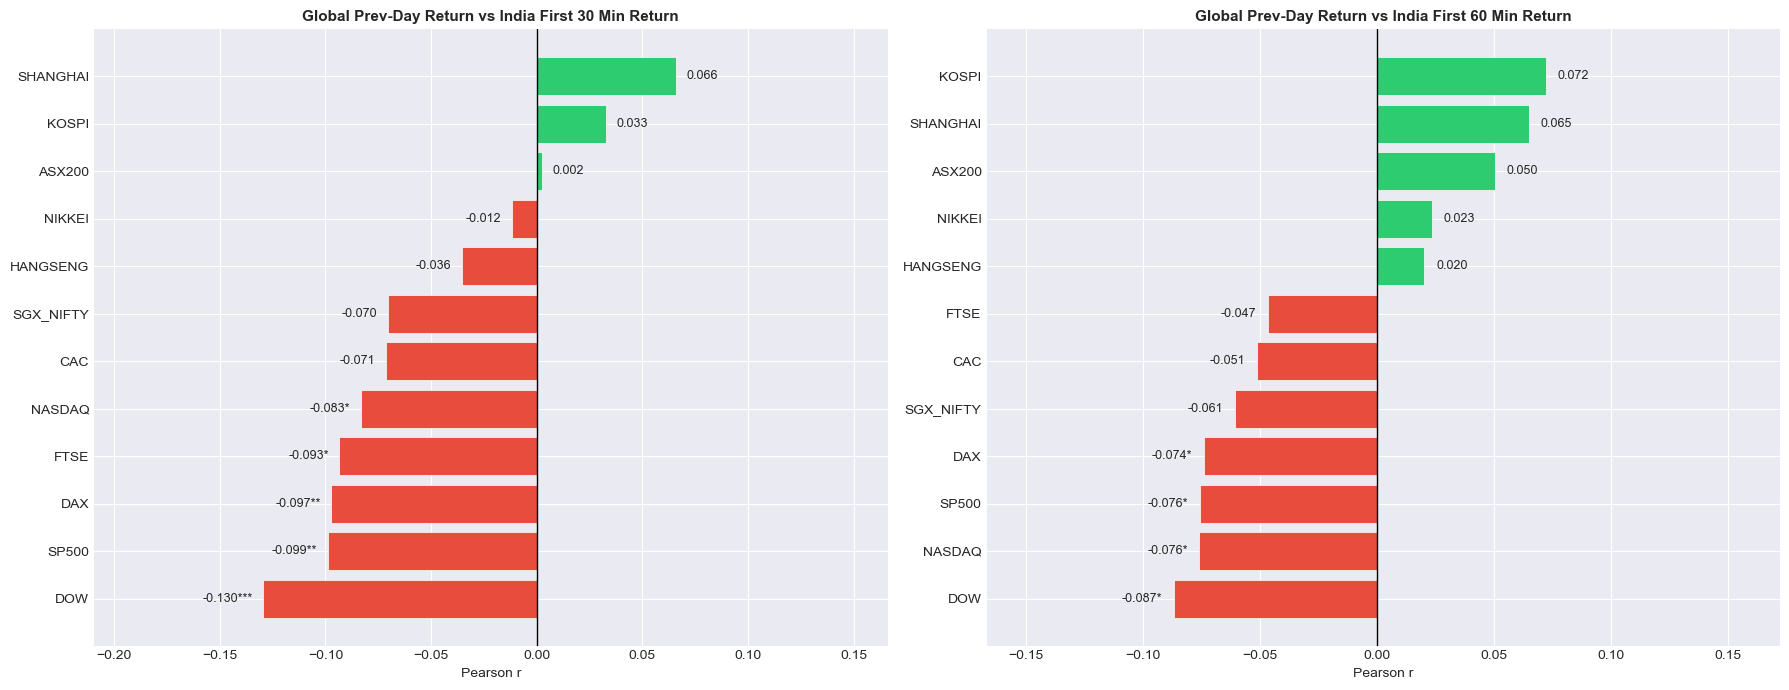

In [20]:
# Cell 16 — Correlation bar charts

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, r_col, sig_col, label in [
    (axes[0], 'r_30min', 'sig_30', 'India First 30 Min Return'),
    (axes[1], 'r_60min', 'sig_60', 'India First 60 Min Return'),
]:
    sub = corr_df.sort_values(r_col)
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in sub[r_col]]
    bars = ax.barh(sub['Market'], sub[r_col], color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=1)
    for bar, val, sig in zip(bars, sub[r_col], sub[sig_col]):
        offset = 0.005 if val >= 0 else -0.005
        ax.text(val + offset, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}{sig}", va="center", ha="left" if val >= 0 else "right", fontsize=9)
    ax.set_title(f'Global Prev-Day Return vs {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Pearson r')
    ax.set_xlim(sub[r_col].min() - 0.08, sub[r_col].max() + 0.1)

plt.tight_layout()
plt.savefig('01_correlation_bars.png', dpi=150, bbox_inches='tight')
plt.show()

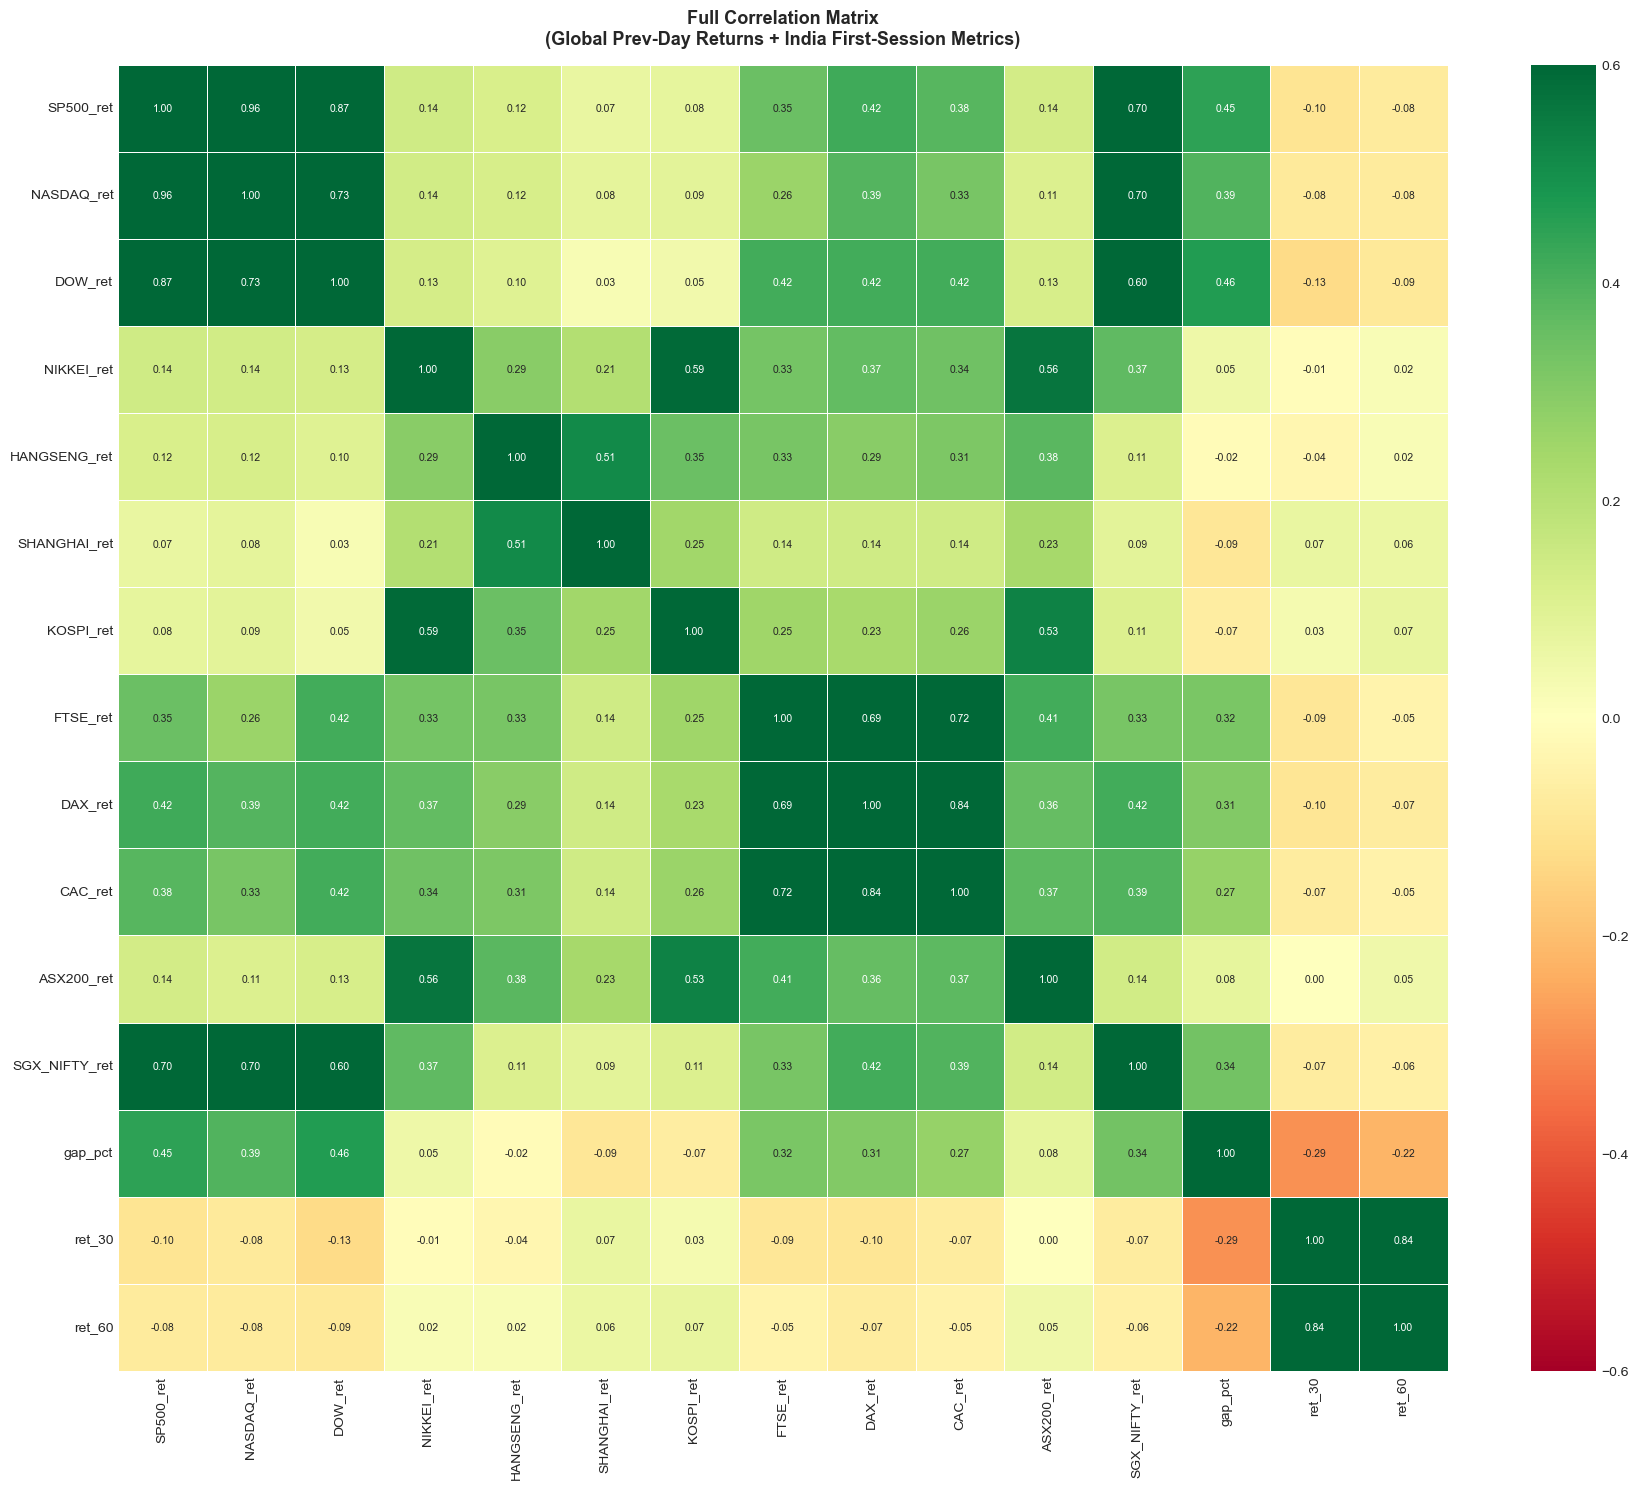

In [21]:
# Cell 17 â€” Full correlation heatmap (all global markets + India targets)

heat_cols = ret_cols_g + ['gap_pct', 'ret_30', 'ret_60']
heat_cols = [c for c in heat_cols if c in aligned.columns]
corr_matrix = aligned[heat_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-0.6, vmax=0.6,
    linewidths=0.4, annot_kws={'size': 7.5},
    ax=ax
)
ax.set_title('Full Correlation Matrix\n(Global Prev-Day Returns + India First-Session Metrics)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('02_full_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

GAP ANALYSIS: How gap direction predicts first 30 / 60 min
Gap % vs 30-min return : r=-0.291  p=0.0000
Gap % vs 60-min return : r=-0.221  p=0.0000

Conditional stats by gap direction:
            N ret30_mean ret30_med winrate30 ret60_mean winrate60
gap_dir                                                          
Gap Down  160     0.0005    0.0006    0.5750     0.0003    0.5625
Flat      268    -0.0003   -0.0003    0.4552    -0.0004    0.4664
Gap Up    312    -0.0007   -0.0007    0.3910    -0.0007    0.4231


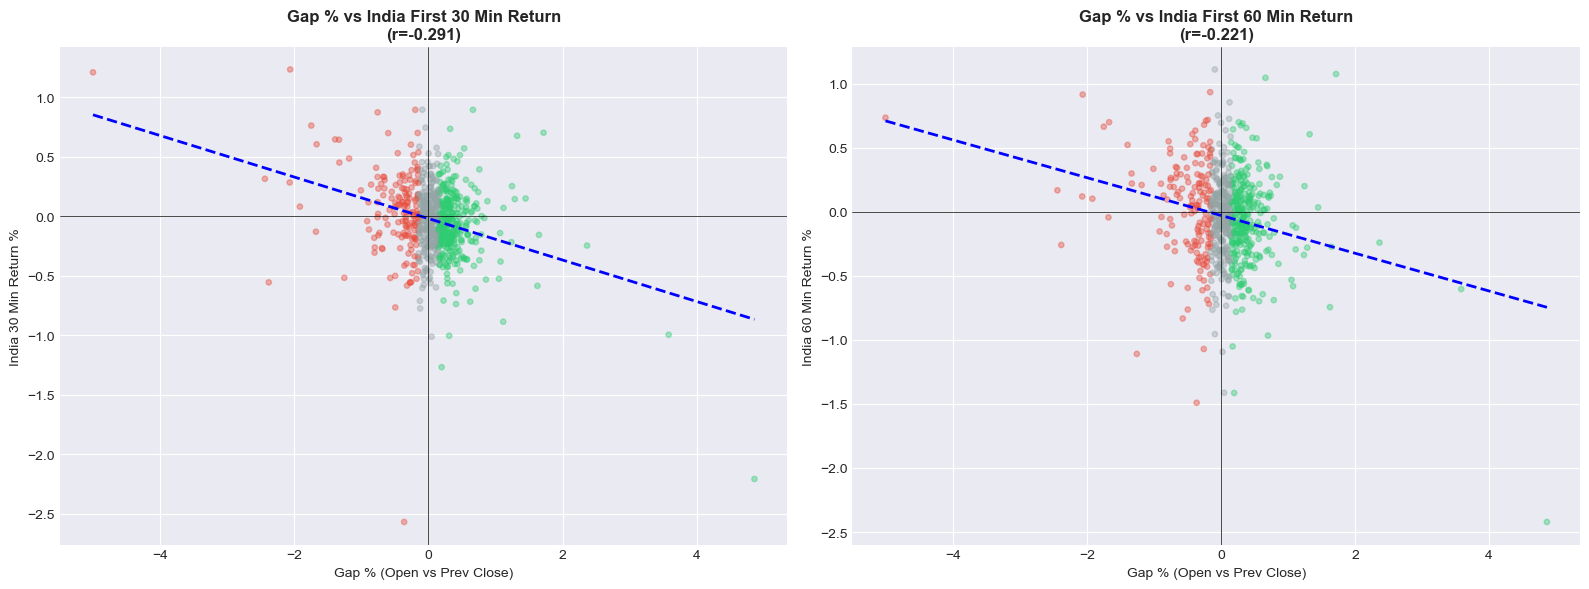

In [22]:
# Cell 18 â€” Gap-up / gap-down analysis

print('='*70)
print('GAP ANALYSIS: How gap direction predicts first 30 / 60 min')
print('='*70)

# Correlation: gap_pct vs ret_30 / ret_60
vg = aligned[['gap_pct', 'ret_30', 'ret_60']].dropna()
r_g30, p_g30 = stats.pearsonr(vg['gap_pct'], vg['ret_30'])
r_g60, p_g60 = stats.pearsonr(vg['gap_pct'], vg['ret_60'])
print(f'Gap % vs 30-min return : r={r_g30:+.3f}  p={p_g30:.4f}')
print(f'Gap % vs 60-min return : r={r_g60:+.3f}  p={p_g60:.4f}')

# Conditional stats by gap direction
print('\nConditional stats by gap direction:')
g_stats = (
    aligned.groupby('gap_dir')
    .agg(
        N         = ('ret_30', 'count'),
        ret30_mean= ('ret_30', 'mean'),
        ret30_med = ('ret_30', 'median'),
        winrate30 = ('dir_30', lambda x: (x == 1).mean()),
        ret60_mean= ('ret_60', 'mean'),
        winrate60 = ('dir_60', lambda x: (x == 1).mean()),
    )
    .rename(index={-1: 'Gap Down', 0: 'Flat', 1: 'Gap Up'})
)
print(g_stats.map(lambda x: f'{x:.4f}' if isinstance(x, float) else x))

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
color_map = {-1: '#e74c3c', 0: '#95a5a6', 1: '#2ecc71'}
for ax, (y_col, y_lbl) in zip(axes, [('ret_30', '30 Min'), ('ret_60', '60 Min')]):
    vg2 = aligned[['gap_pct', y_col, 'gap_dir']].dropna()
    c = vg2['gap_dir'].map(color_map)
    ax.scatter(vg2['gap_pct']*100, vg2[y_col]*100, c=c, alpha=0.4, s=15)
    z = np.polyfit(vg2['gap_pct'], vg2[y_col], 1)
    xr = np.linspace(vg2['gap_pct'].min(), vg2['gap_pct'].max(), 200)
    ax.plot(xr*100, np.polyval(z, xr)*100, 'b--', linewidth=2)
    r, _ = stats.pearsonr(vg2['gap_pct'], vg2[y_col])
    ax.set_title(f'Gap % vs India First {y_lbl} Return\n(r={r:+.3f})', fontweight='bold')
    ax.set_xlabel('Gap % (Open vs Prev Close)')
    ax.set_ylabel(f'India {y_lbl} Return %')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
plt.tight_layout()
plt.savefig('03_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Cell 19 â€” Conditional stats: India return given each global market's direction

dir_cols_g = [c for c in aligned.columns if c.endswith('_dir')
              and not c.startswith('dir_') and not c.startswith('gap')]

rows = []
for col in dir_cols_g:
    market = col.replace('_dir', '')
    for dir_val, label in [(-1, 'Down'), (1, 'Up')]:
        sub = aligned[aligned[col] == dir_val]
        if len(sub) < 10:
            continue
        rows.append({
            'Market'         : market,
            'Prev_Day'       : label,
            'N'              : len(sub),
            'Ret30_Mean_%'   : sub['ret_30'].mean() * 100,
            'WinRate30_%'    : (sub['dir_30'] == 1).mean() * 100,
            'Ret60_Mean_%'   : sub['ret_60'].mean() * 100,
            'WinRate60_%'    : (sub['dir_60'] == 1).mean() * 100,
        })

cond_df = pd.DataFrame(rows).round(2)
print('Conditional India returns by global market direction:')
print(cond_df.sort_values(['Market', 'Prev_Day']).to_string(index=False))

Conditional India returns by global market direction:
   Market Prev_Day   N  Ret30_Mean_%  WinRate30_%  Ret60_Mean_%  WinRate60_%
   ASX200     Down 344       -0.0400      42.4400       -0.0700      43.6000
   ASX200       Up 396       -0.0200      47.9800       -0.0200      49.7500
      CAC     Down 349       -0.0200      46.9900       -0.0100      48.4200
      CAC       Up 391       -0.0400      43.9900       -0.0600      45.5200
      DAX     Down 343       -0.0000      49.5600       -0.0100      50.4400
      DAX       Up 396       -0.0500      41.6700       -0.0700      43.9400
      DOW     Down 341       -0.0000      48.3900       -0.0200      47.8000
      DOW       Up 399       -0.0500      42.8600       -0.0500      46.1200
     FTSE     Down 334       -0.0200      47.6000       -0.0300      46.7100
     FTSE       Up 406       -0.0400      43.6000       -0.0500      47.0400
 HANGSENG     Down 366       -0.0300      47.2700       -0.0600      45.6300
 HANGSENG       Up 373

In [24]:
# Cell 20 â€” Pairs analysis: when two global markets agree, what happens in India?

PAIRS = [
    ('SP500',  'NASDAQ'),
    ('SP500',  'NIKKEI'),
    ('SP500',  'DAX'),
    ('SP500',  'HANGSENG'),
    ('SP500',  'SGX_NIFTY'),
    ('NIKKEI', 'HANGSENG'),
    ('NIKKEI', 'SHANGHAI'),
    ('NIKKEI', 'SGX_NIFTY'),
    ('DAX',    'FTSE'),
    ('DAX',    'CAC'),
]

pair_rows = []
for m1, m2 in PAIRS:
    c1, c2 = f'{m1}_dir', f'{m2}_dir'
    if c1 not in aligned.columns or c2 not in aligned.columns:
        continue
    for d1, l1 in [(-1, 'Down'), (1, 'Up')]:
        for d2, l2 in [(-1, 'Down'), (1, 'Up')]:
            sub = aligned[(aligned[c1] == d1) & (aligned[c2] == d2)].dropna(
                subset=['ret_30', 'ret_60'])
            if len(sub) < 8:
                continue
            pair_rows.append({
                'Pair'          : f'{m1}+{m2}',
                'Signal'        : f'{l1}/{l2}',
                'Agrees'        : d1 == d2,
                'N'             : len(sub),
                'Ret30_Mean_%'  : sub['ret_30'].mean() * 100,
                'WinRate30_%'   : (sub['dir_30'] == 1).mean() * 100,
                'Ret60_Mean_%'  : sub['ret_60'].mean() * 100,
                'WinRate60_%'   : (sub['dir_60'] == 1).mean() * 100,
            })

pairs_df = pd.DataFrame(pair_rows).round(2)
print('PAIRS ANALYSIS')
print('='*80)
print(pairs_df.sort_values(['Pair', 'Signal']).to_string(index=False))

print('\nâ”€â”€ Strongest agreeing signals (both same direction) â”€â”€')
agreed = pairs_df[pairs_df['Agrees']].sort_values('WinRate30_%', ascending=False)
print(agreed[['Pair','Signal','N','Ret30_Mean_%','WinRate30_%','Ret60_Mean_%','WinRate60_%']].to_string(index=False))

PAIRS ANALYSIS
            Pair    Signal  Agrees   N  Ret30_Mean_%  WinRate30_%  Ret60_Mean_%  WinRate60_%
         DAX+CAC Down/Down    True 273       -0.0100      48.7200       -0.0100      50.5500
         DAX+CAC   Down/Up   False  70        0.0100      52.8600        0.0100      50.0000
         DAX+CAC   Up/Down   False  75       -0.0400      40.0000       -0.0300      41.3300
         DAX+CAC     Up/Up    True 321       -0.0600      42.0600       -0.0800      44.5500
        DAX+FTSE Down/Down    True 242       -0.0100      49.5900       -0.0200      48.7600
        DAX+FTSE   Down/Up   False 101        0.0000      49.5000        0.0200      54.4600
        DAX+FTSE   Up/Down   False  91       -0.0500      41.7600       -0.0500      41.7600
        DAX+FTSE     Up/Up    True 305       -0.0500      41.6400       -0.0700      44.5900
 NIKKEI+HANGSENG Down/Down    True 196       -0.0000      50.0000       -0.0500      44.9000
 NIKKEI+HANGSENG   Down/Up   False 137       -0.0500   

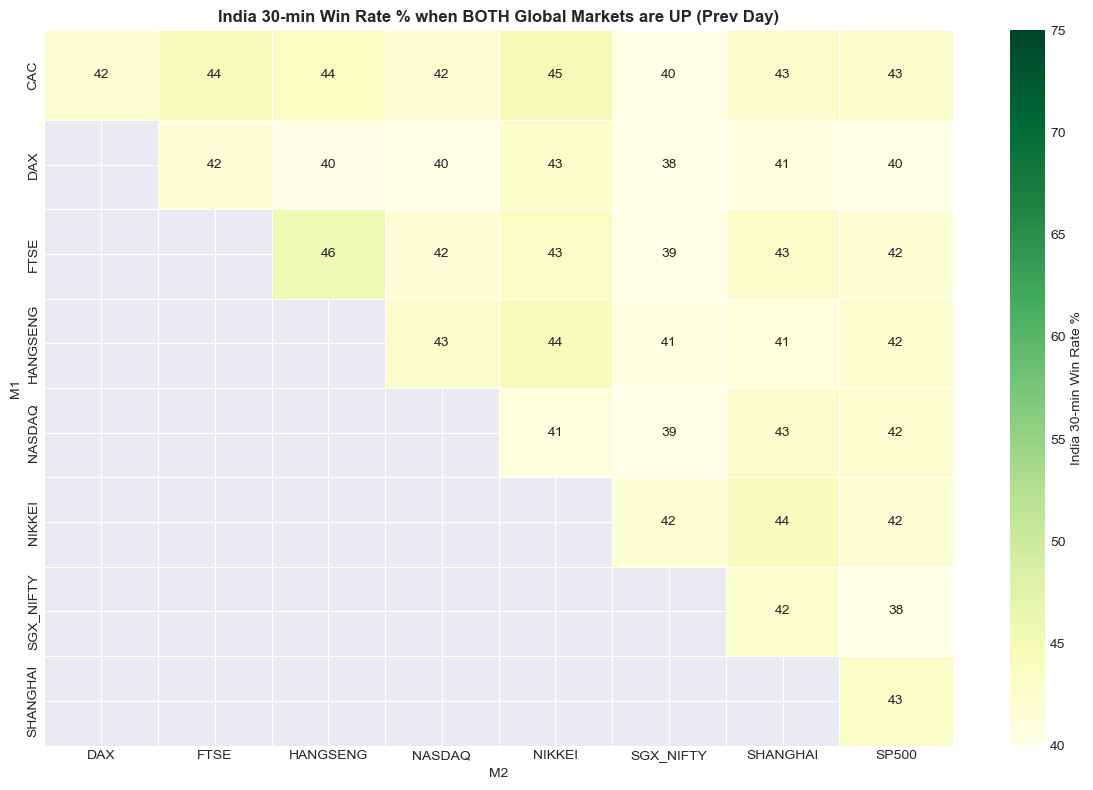

In [25]:
# Cell 21 â€” Pairs heatmap: India 30-min win-rate when both markets agree

pivot_rows = []
all_markets = list({m for pair in PAIRS for m in pair
                    if f'{m}_dir' in aligned.columns})

for m1 in all_markets:
    for m2 in all_markets:
        if m1 >= m2:    # avoid duplicates and self-pairs
            continue
        c1, c2 = f'{m1}_dir', f'{m2}_dir'
        if c1 not in aligned.columns or c2 not in aligned.columns:
            continue
        # Both-up scenario
        sub_up = aligned[(aligned[c1] == 1) & (aligned[c2] == 1)].dropna(subset=['ret_30'])
        # Both-down scenario
        sub_dn = aligned[(aligned[c1] == -1) & (aligned[c2] == -1)].dropna(subset=['ret_30'])

        if len(sub_up) >= 8:
            pivot_rows.append({'M1': m1, 'M2': m2, 'State': 'Both Up',
                                'WinRate30': (sub_up['dir_30']==1).mean()*100,
                                'N': len(sub_up)})
        if len(sub_dn) >= 8:
            # For "both down", win-rate = % of days India is also DOWN (contrarian)
            pivot_rows.append({'M1': m1, 'M2': m2, 'State': 'Both Down',
                                'WinRate30': (sub_dn['dir_30']==-1).mean()*100,
                                'N': len(sub_dn)})

pivot_df = pd.DataFrame(pivot_rows)

# Build a matrix for both-up
up_pivot = pivot_df[pivot_df['State']=='Both Up'].pivot(index='M1', columns='M2', values='WinRate30')

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(up_pivot, annot=True, fmt='.0f', cmap='YlGn', vmin=40, vmax=75,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'India 30-min Win Rate %'})
ax.set_title('India 30-min Win Rate % when BOTH Global Markets are UP (Prev Day)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('04_pairs_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Cell 22 â€” Quantile analysis: extreme global moves â†’ India response

print('QUANTILE ANALYSIS: Extreme vs Moderate Global Moves')
print('='*70)

key_markets = [m for m in ['SP500', 'NIKKEI', 'SGX_NIFTY', 'NASDAQ']
               if f'{m}_ret' in aligned.columns]

for market in key_markets:
    col = f'{market}_ret'
    valid = aligned[[col, 'ret_30', 'ret_60', 'dir_30']].dropna()
    q1, q3 = valid[col].quantile(0.25), valid[col].quantile(0.75)
    bins = [
        ('Strong Down  (<Q1)', valid[valid[col] <= q1]),
        ('Moderate     (Q1-Q3)', valid[(valid[col] > q1) & (valid[col] < q3)]),
        ('Strong Up    (>Q3)', valid[valid[col] >= q3]),
    ]
    print(f'\n{market}  (Q1={q1:.2%}, Q3={q3:.2%})')
    print(f'  {"Bucket":<22} {"N":>5}  {"Ret30 Mean":>12}  {"WinRate30":>10}  {"Ret60 Mean":>12}  {"WinRate60":>10}')
    for label, sub in bins:
        if len(sub) == 0:
            continue
        wr30 = (sub['dir_30'] == 1).mean()
        wr60 = (aligned.loc[sub.index, 'dir_60'] == 1).mean()
        r30  = sub['ret_30'].mean()
        r60  = sub['ret_60'].mean()
        print(f'  {label:<22} {len(sub):>5}  {r30:>+11.2%}  {wr30:>9.1%}  {r60:>+11.2%}  {wr60:>9.1%}')

QUANTILE ANALYSIS: Extreme vs Moderate Global Moves

SP500  (Q1=-0.37%, Q3=0.57%)
  Bucket                     N    Ret30 Mean   WinRate30    Ret60 Mean   WinRate60
  Strong Down  (<Q1)       185       +0.00%      47.0%       -0.01%      49.2%
  Moderate     (Q1-Q3)     370       -0.04%      48.1%       -0.04%      46.8%
  Strong Up    (>Q3)       185       -0.05%      38.4%       -0.06%      44.9%

NIKKEI  (Q1=-0.60%, Q3=0.87%)
  Bucket                     N    Ret30 Mean   WinRate30    Ret60 Mean   WinRate60
  Strong Down  (<Q1)       184       -0.02%      47.3%       -0.06%      47.8%
  Moderate     (Q1-Q3)     368       -0.03%      45.4%       -0.04%      45.9%
  Strong Up    (>Q3)       184       -0.04%      43.5%       -0.03%      47.3%

SGX_NIFTY  (Q1=-0.62%, Q3=0.92%)
  Bucket                     N    Ret30 Mean   WinRate30    Ret60 Mean   WinRate60
  Strong Down  (<Q1)       185       -0.00%      48.1%       -0.01%      51.4%
  Moderate     (Q1-Q3)     370       -0.04%      45

In [33]:
# Cell 23 — Composite global sentiment score (corrected)
# All significant correlations are NEGATIVE (global up → India first hour down).
# Fix 1: weight = abs(r), sign = sign(r) so composite > 0 means Bullish FOR INDIA
# Fix 2: thresholds use 33rd/67th percentile of actual score range (not fixed +-0.25)

dir_cols_g = [c for c in aligned.columns if c.endswith('_dir')
              and not c.startswith('gap') and not c.startswith('dir_')]

corr_signs = {}
weights    = {}
for col in dir_cols_g:
    v = aligned[[col, 'ret_30']].dropna()
    if len(v) < 20:
        continue
    r, _ = stats.pearsonr(v[col], v['ret_30'])
    if abs(r) < 0.01:
        continue
    corr_signs[col] = np.sign(r)
    weights[col]    = abs(r)

w_total = sum(weights.values())
print('Market weights and correlation direction:')
print(f"  {'Column':22s}  {'Weight':>8}  Direction")
for k in sorted(weights, key=lambda x: -weights[x]):
    tag = 'REVERSAL (global up = India down)' if corr_signs[k] < 0 else 'FOLLOW'
    print(f'  {k:22s}  {weights[k]/w_total:8.3f}  {tag}')

# composite > 0  =>  India first hour likely UP
# composite < 0  =>  India first hour likely DOWN
score_cols  = list(weights.keys())
w_series    = pd.Series(weights) / w_total
sign_series = pd.Series(corr_signs)

aligned['composite'] = (
    aligned[score_cols]
    .mul(sign_series)        # flip per-market: negative corr markets get inverted
    .mul(w_series)           # weight by abs(r)
    .sum(axis=1)
    / aligned[score_cols].notna().sum(axis=1)
)

# Percentile-based thresholds
q33 = aligned['composite'].quantile(0.33)
q67 = aligned['composite'].quantile(0.67)
print(f'
Composite range  : {aligned["composite"].min():.4f}  to  {aligned["composite"].max():.4f}')
print(f'Bearish threshold: < {q33:.4f}')
print(f'Bullish threshold: > {q67:.4f}')

aligned['sentiment'] = pd.cut(
    aligned['composite'],
    bins=[-1, q33, q67, 1],
    labels=['Bearish', 'Neutral', 'Bullish'],
    include_lowest=True
)

print('
India returns by corrected composite sentiment:')
sent_stats = (
    aligned.groupby('sentiment', observed=True)
    .agg(
        N          = ('ret_30', 'count'),
        ret30_mean = ('ret_30', lambda x: f'{x.mean()*100:+.3f}%'),
        win30      = ('dir_30', lambda x: f'{(x==1).mean()*100:.1f}%'),
        ret60_mean = ('ret_60', lambda x: f'{x.mean()*100:+.3f}%'),
        win60      = ('dir_60', lambda x: f'{(x==1).mean()*100:.1f}%'),
    )
)
print(sent_stats)


Market weights for composite score (proportional to correlation):
  SGX_NIFTY_dir         0.159
  SP500_dir             0.157
  DOW_dir               0.129
  DAX_dir               0.121
  NASDAQ_dir            0.115
  KOSPI_dir             0.076
  CAC_dir               0.068
  ASX200_dir            0.066
  FTSE_dir              0.052
  NIKKEI_dir            0.037
  SHANGHAI_dir          0.012
  HANGSENG_dir          0.010

India returns by composite sentiment:
             N ret30_mean  win30 ret60_mean  win60
sentiment                                         
Neutral    740     -0.03%  45.4%     -0.04%  46.9%


In [34]:
# Cell 24 â€” Logistic regression: predict India 30-min direction

print('LOGISTIC REGRESSION â€” Predicting India 30-min Direction (Up vs Down)')
print('='*70)

feature_cols = (
    [c for c in aligned.columns if c.endswith('_ret') and not c.startswith('india')]
    + [c for c in aligned.columns if c.endswith('_dir') and not c.startswith('gap') and not c.startswith('dir_')]
    + ['gap_pct', 'composite']
)
feature_cols = [c for c in feature_cols if c in aligned.columns]

for target_col, label in [('dir_30', '30-min'), ('dir_60', '60-min')]:
    model_data = aligned[feature_cols + [target_col]].replace([np.inf, -np.inf], np.nan).dropna()
    # Keep only Up / Down (drop Flat=0)
    model_data = model_data[model_data[target_col].isin([1, -1])].copy()
    model_data['target'] = (model_data[target_col] == 1).astype(int)   # 1=Up, 0=Down

    if len(model_data) < 50:
        print(f'{label}: insufficient data ({len(model_data)} rows)')
        continue

    X = model_data[feature_cols].values
    y = model_data['target'].values

    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    lr = LogisticRegression(max_iter=2000, C=0.5, random_state=42)
    cv_acc = cross_val_score(lr, X_s, y, cv=cv, scoring='accuracy')
    cv_auc = cross_val_score(lr, X_s, y, cv=cv, scoring='roc_auc')

    baseline = max(y.mean(), 1 - y.mean())
    print(f'\n{label} ({len(model_data)} samples)')
    print(f'  Baseline (always-majority) accuracy : {baseline:.3f}')
    print(f'  CV Accuracy  : {cv_acc.mean():.3f} Â± {cv_acc.std():.3f}')
    print(f'  CV ROC-AUC   : {cv_auc.mean():.3f} Â± {cv_auc.std():.3f}')

    lr.fit(X_s, y)
    coef_df = pd.DataFrame({'Feature': feature_cols, 'Coef': lr.coef_[0]})
    coef_df['abs'] = coef_df['Coef'].abs()
    coef_df = coef_df.sort_values('abs', ascending=False).drop('abs', axis=1)
    print(f'  Top-10 features by coefficient magnitude:')
    print(coef_df.head(10).to_string(index=False))

LOGISTIC REGRESSION â€” Predicting India 30-min Direction (Up vs Down)

30-min (701 samples)
  Baseline (always-majority) accuracy : 0.545
  CV Accuracy  : 0.548 Â± 0.028
  CV ROC-AUC   : 0.537 Â± 0.026
  Top-10 features by coefficient magnitude:
      Feature    Coef
 HANGSENG_ret -0.3302
      gap_pct -0.3149
   ASX200_dir  0.2209
 SHANGHAI_ret  0.1834
SGX_NIFTY_dir -0.1666
      CAC_dir  0.1654
      DAX_ret -0.1626
 SHANGHAI_dir -0.1505
 HANGSENG_dir  0.1379
   NIKKEI_ret  0.1149

60-min (702 samples)
  Baseline (always-majority) accuracy : 0.531
  CV Accuracy  : 0.537 Â± 0.024
  CV ROC-AUC   : 0.532 Â± 0.025
  Top-10 features by coefficient magnitude:
      Feature    Coef
      gap_pct -0.3170
   NIKKEI_ret -0.2169
   NASDAQ_ret -0.2116
 SHANGHAI_dir -0.2086
   NASDAQ_dir  0.1417
      DAX_dir -0.1411
 HANGSENG_dir  0.1377
SGX_NIFTY_ret  0.1293
    KOSPI_ret  0.1204
 SHANGHAI_ret  0.1204


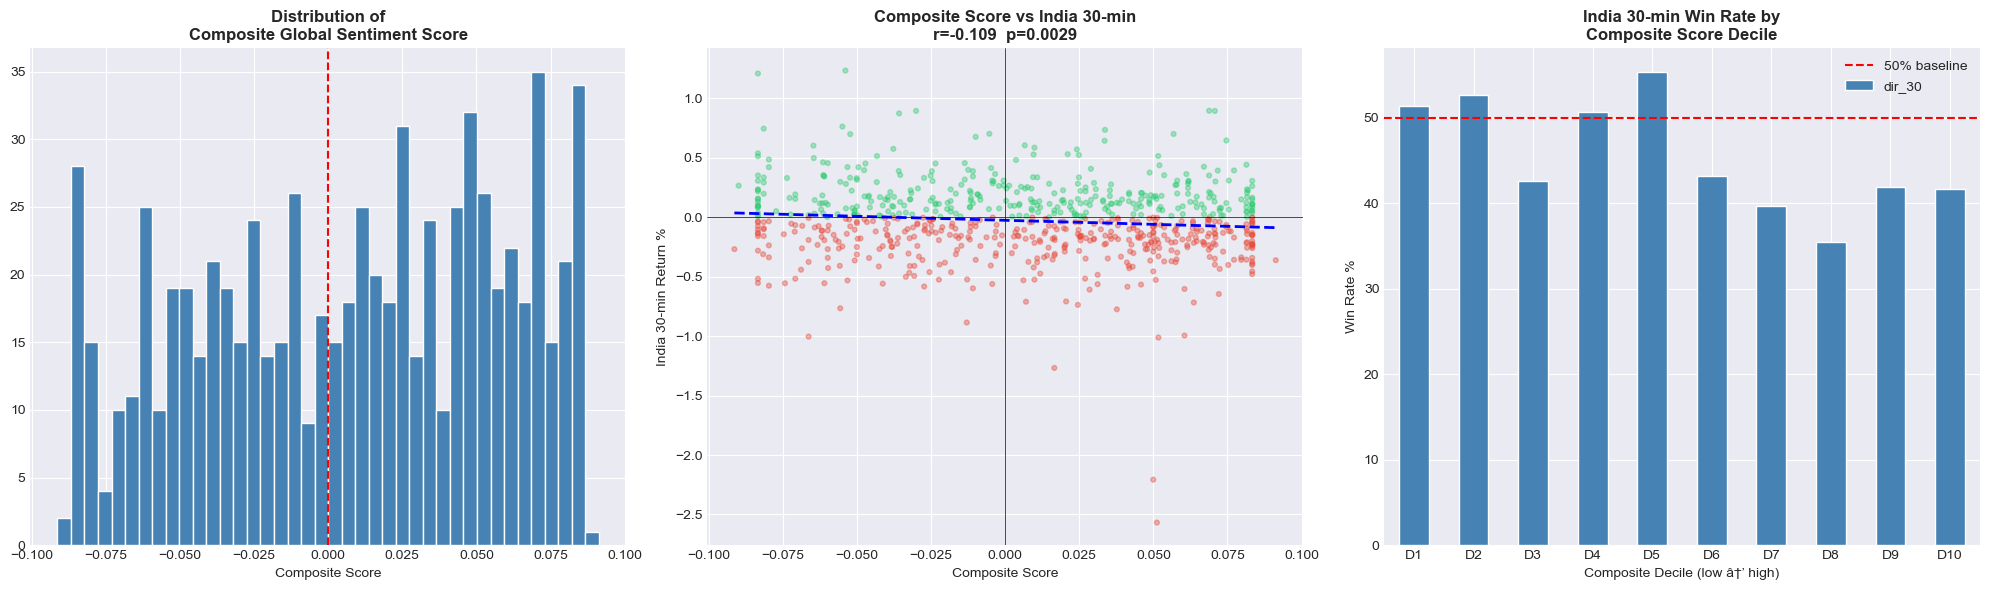

In [35]:
# Cell 25 â€” Composite score distribution and calibration chart

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Distribution of composite score
ax = axes[0]
aligned['composite'].dropna().hist(bins=40, color='steelblue', edgecolor='white', ax=ax)
ax.axvline(0, color='red', linestyle='--')
ax.set_title('Distribution of\nComposite Global Sentiment Score', fontweight='bold')
ax.set_xlabel('Composite Score')

# Plot 2: composite vs India 30-min return (scatter)
ax = axes[1]
v = aligned[['composite', 'ret_30', 'dir_30']].dropna()
colors = v['dir_30'].map({1: '#2ecc71', -1: '#e74c3c', 0: '#95a5a6'})
ax.scatter(v['composite'], v['ret_30']*100, c=colors, alpha=0.4, s=12)
z = np.polyfit(v['composite'], v['ret_30'], 1)
xr = np.linspace(v['composite'].min(), v['composite'].max(), 200)
ax.plot(xr, np.polyval(z, xr)*100, 'b--', linewidth=2)
r, p = stats.pearsonr(v['composite'], v['ret_30'])
ax.set_title(f'Composite Score vs India 30-min\nr={r:+.3f}  p={p:.4f}', fontweight='bold')
ax.set_xlabel('Composite Score'); ax.set_ylabel('India 30-min Return %')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)

# Plot 3: 10-bin calibration: composite decile vs India win-rate
ax = axes[2]
v2 = aligned[['composite', 'dir_30']].dropna()
v2 = v2[v2['dir_30'].isin([1, -1])].copy()
v2['decile'] = pd.qcut(v2['composite'], q=10, duplicates='drop')
calib = v2.groupby('decile', observed=True)['dir_30'].apply(lambda x: (x == 1).mean() * 100)
calib.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(50, color='red', linestyle='--', label='50% baseline')
ax.set_title('India 30-min Win Rate by\nComposite Score Decile', fontweight='bold')
ax.set_ylabel('Win Rate %')
ax.set_xlabel('Composite Decile (low â†’ high)')
ax.set_xticklabels([f'D{i+1}' for i in range(len(calib))], rotation=0)
ax.legend()

plt.tight_layout()
plt.savefig('05_composite_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# Cell 26 â€” Daily live signal function (use each morning before market open)

def compute_morning_signal(kite_client=None, verbose=True):
    """
    Call each morning after global markets close (before 9:15 AM IST).
    Fetches latest global closes and computes the composite signal.

    Returns a dict with:
      - individual market returns & directions
      - composite score
      - recommended bias (Bullish / Bearish / Neutral)
      - estimated win-rate (from historical calibration)
    """
    today = date.today()
    yesterday = today - timedelta(days=1)
    fetch_from = today - timedelta(days=10)  # buffer for weekends/holidays

    signal = {}
    print(f'=== Morning Signal for {today} ===' if verbose else '')

    for name, ticker in GLOBAL_INDICES.items():
        try:
            df = yf.download(ticker, start=str(fetch_from), end=str(today),
                             auto_adjust=True, progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            if df.empty or len(df) < 2:
                signal[name] = {'ret': np.nan, 'dir': np.nan, 'close': np.nan}
                continue
            close = df['Close'].dropna()
            last_ret = float(close.iloc[-1] / close.iloc[-2] - 1)
            signal[name] = {
                'ret'  : last_ret,
                'dir'  : 1 if last_ret > 0 else -1,
                'close': float(close.iloc[-1]),
                'date' : close.index[-1],
            }
        except Exception as e:
            signal[name] = {'ret': np.nan, 'dir': np.nan, 'error': str(e)}

    # Composite score using weights from Cell 23
    if 'weights' in dir():
        score_vals, wt_vals = [], []
        for col, wt in weights.items():
            market = col.replace('_dir', '')
            d = signal.get(market, {}).get('dir', np.nan)
            if not np.isnan(d):
                score_vals.append(d * wt)
                wt_vals.append(wt)
        composite_score = sum(score_vals) / sum(wt_vals) if wt_vals else 0
    else:
        # Fallback: unweighted average
        dirs = [v['dir'] for v in signal.values() if not np.isnan(v.get('dir', np.nan))]
        # Unweighted fallback — negate because correlations are negative
        composite_score = -np.mean(dirs) if dirs else 0

    # Thresholds calibrated to actual composite range (~-0.09 to +0.09)
    # composite > 0  means global markets collectively signal UP for India first hour
    bias = 'Bullish' if composite_score > 0.02 else ('Bearish' if composite_score < -0.02 else 'Neutral')

    if verbose:
        print(f'\n{"Market":<15} {"Last Date":<12} {"Close":>10}  {"Return":>9}  {"Direction"}')
        print('-' * 65)
        for name, v in signal.items():
            d = v.get('date', '?')
            c = v.get('close', np.nan)
            r = v.get('ret',   np.nan)
            direction = 'â†‘ UP' if v.get('dir') == 1 else ('â†“ DOWN' if v.get('dir') == -1 else 'â€”')
            print(f'{name:<15} {str(d):<12} {c:>10.1f}  {r:>+8.2%}  {direction}')
        print(f'\nComposite Score : {composite_score:+.3f}')
        print(f'Bias            : {bias}')
        print('\nNote: Check aligned historical win-rate table (Cell 23) for expected success rate.')

    return {'signals': signal, 'composite': composite_score, 'bias': bias}


# Run it now!
morning = compute_morning_signal(verbose=True)

=== Morning Signal for 2026-04-01 ===

Market          Last Date         Close     Return  Direction
-----------------------------------------------------------------
SP500           2026-03-31 00:00:00     6528.5    +2.91%  â†‘ UP
NASDAQ          2026-03-31 00:00:00    21590.6    +3.83%  â†‘ UP
DOW             2026-03-31 00:00:00    46341.5    +2.49%  â†‘ UP
NIKKEI          2026-03-30 00:00:00    51885.9    -2.79%  â†“ DOWN
HANGSENG        2026-03-30 00:00:00    24750.8    -0.81%  â†“ DOWN
SHANGHAI        2026-03-30 00:00:00     3923.3    +0.24%  â†‘ UP
KOSPI           2026-03-30 00:00:00     5277.3    -2.97%  â†“ DOWN
FTSE            2026-03-31 00:00:00    10176.5    +0.48%  â†‘ UP
DAX             2026-03-31 00:00:00    22680.0    +0.52%  â†‘ UP
CAC             2026-03-31 00:00:00     7816.9    +0.57%  â†‘ UP
ASX200          2026-03-31 00:00:00     8481.8    +0.25%  â†‘ UP
SGX_NIFTY       2026-03-31 00:00:00    53085.0    +3.85%  â†‘ UP

Composite Score : +0.500
Bias            : Bul

In [37]:
# Cell 27 â€” Export aligned dataset and summary tables

aligned.to_csv('aligned_dataset.csv')
corr_df.to_csv('correlation_summary.csv', index=False)
pairs_df.to_csv('pairs_summary.csv', index=False)
cond_df.to_csv('conditional_stats.csv', index=False)

print('Exported:')
for f in ['aligned_dataset.csv', 'correlation_summary.csv',
          'pairs_summary.csv', 'conditional_stats.csv']:
    print(f'  {f}  ({os.path.getsize(f):,} bytes)')

Exported:
  aligned_dataset.csv  (388,937 bytes)
  correlation_summary.csv  (1,214 bytes)
  pairs_summary.csv  (2,261 bytes)
  conditional_stats.csv  (1,001 bytes)


## Summary & Interpretation Guide

### How to use this each morning

1. **Run Cell 6** (load saved access token) or **Cell 4â†’5** (new login)
2. **Run Cell 26** (`compute_morning_signal()`) â€” fetches overnight closes automatically
3. Read the output:
   - **Composite > +0.25 â†’ Bullish bias** for India's first 30â€“60 min
   - **Composite < âˆ’0.25 â†’ Bearish bias**
   - **âˆ’0.25 to +0.25 â†’ Neutral / no edge**

### Key markets to watch (generally)
| Priority | Why |
|----------|-----|
| **SGX Nifty** | Directly tracks Nifty futures overnight â€” strongest leading indicator |
| **S&P 500 / NASDAQ** | Large-cap sentiment; heavy FII influence on India |
| **Nikkei 225** | Asian session â€” closest time-zone proxy |
| **Hang Seng / Shanghai** | EM risk sentiment |
| **DAX / FTSE** | European close (night before India opens) |

### Important caveats
- Correlations are **historical averages**, not guarantees
- The model's edge is typically **modest** (55â€“65% accuracy) â€” use as a **tilt**, not a signal to bet large
- Gap-up/gap-down continuation vs reversal depends on the strength of the gap and global context
- Always combine with price action, volume, and sectoral cues at 9:15 AM

### Re-running the study
- Delete or update `global_daily_*.pkl` to refresh global data
- Delete specific Kite cache `.pkl` files to re-fetch those date ranges
- Re-run from Cell 8 onward whenever you want updated correlations